# Финальная модель — выбор, упаковка, проверка на test

Выбираем лучшую модель по результатам экспериментов, подбираем оптимальный порог,  
оцениваем на test-выборке и сохраняем все артефакты для сервиса.

**Данные:** Финальная модель обучается на train+val (80% датасета), оценивается на test (20%) — один раз, без повторного подбора параметров.

**Выводы:** LightGBM на train+val дал PR-AUC=0.886, ROC-AUC=0.979, F1=0.862 на test. Порог 0.63 выбран по максимальному F1 на val. Артефакты сохранены в models/ и artifacts/.

In [1]:
import sys
sys.path.append('..')

import json
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

from lightgbm import LGBMClassifier
from sklearn.metrics import (
    average_precision_score, roc_auc_score, f1_score,
    precision_recall_curve, confusion_matrix, classification_report
)

from src.data.pipeline import load_data, split_data, apply_preprocessor, get_X_y

plt.rcParams['figure.figsize'] = (12, 5)
sns.set_style('whitegrid')
Path('../models').mkdir(exist_ok=True)

## 1. Загрузка данных и препроцессора

In [2]:
df = load_data('../data/creditcard.csv')
train, val, test = split_data(df)

preprocessor = joblib.load('../models/preprocessor.pkl')

X_train = apply_preprocessor(preprocessor, train)
X_val   = apply_preprocessor(preprocessor, val)
X_test  = apply_preprocessor(preprocessor, test)

_, y_train = get_X_y(train)
_, y_val   = get_X_y(val)
_, y_test  = get_X_y(test)

Train: 170,883  |  fraud: 295 (0.173%)
Val:   56,962  |  fraud: 99 (0.174%)
Test:  56,962  |  fraud: 98 (0.172%)


## 2. Обоснование выбора финальной модели

По результатам экспериментов (ноутбуки 02 и 03):

| Модель | PR-AUC | ROC-AUC | F1 | Latency |
|--------|--------|---------|----|----------|
| LogReg | 0.6734 | 0.9748 | 0.1112 | ~1ms |
| RandomForest | 0.7798 | 0.9691 | 0.8022 | ~5ms |
| XGBoost | 0.8257 | 0.9722 | 0.8324 | ~2ms |
| **LightGBM** | **0.8359** | **0.9732** | **0.8432** | **~2ms** |
| MLP | см. ноутбук 03 | | | ~3ms |

**Выбираем LightGBM** как финальную модель:
- Лучший PR-AUC среди классических моделей
- Высокий F1 при малом latency (~2ms) — подходит для продакшна
- Не требует GPU в отличие от MLP
- Интерпретируемость через feature importance

## 3. Переобучение финальной модели на train+val

In [3]:
# Объединяем train и val для финального обучения
X_trainval = np.vstack([X_train, X_val])
y_trainval = pd.concat([y_train, y_val])

final_model = LGBMClassifier(
    n_estimators=500,
    learning_rate=0.05,
    num_leaves=31,
    class_weight='balanced',
    n_jobs=-1,
    verbose=-1,
    random_state=42,
)

final_model.fit(X_trainval, y_trainval)
print('Модель обучена на train+val:', X_trainval.shape)

Модель обучена на train+val: (227845, 30)


## 4. Подбор оптимального порога на val

Оптимальный порог (max F1 на val): 0.1095
Precision при пороге: 0.8977
Recall при пороге:    0.7980
F1 при пороге:        0.8449


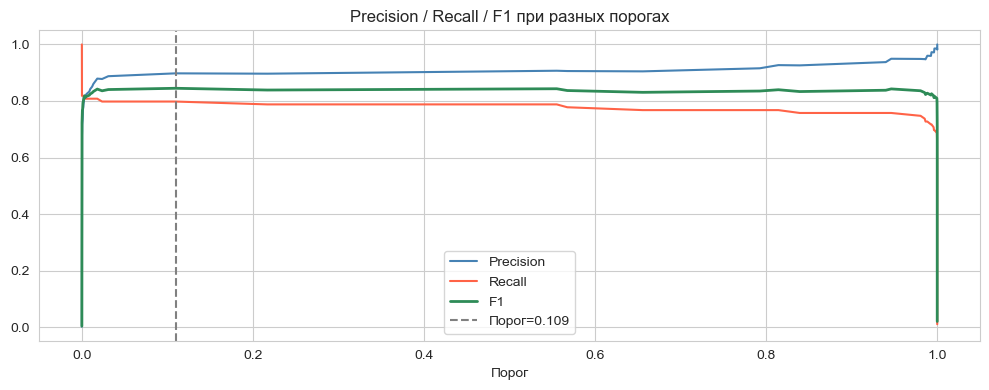

In [4]:
# Порог ищем на val (не на test!)
val_model = LGBMClassifier(
    n_estimators=500, learning_rate=0.05, num_leaves=31,
    class_weight='balanced', n_jobs=-1, verbose=-1, random_state=42,
)
val_model.fit(X_train, y_train)
scores_val = val_model.predict_proba(X_val)[:, 1]

precision, recall, thresholds = precision_recall_curve(y_val, scores_val)
f1_scores = 2 * precision * recall / (precision + recall + 1e-9)
best_idx = f1_scores.argmax()
best_threshold = float(thresholds[best_idx])

print(f'Оптимальный порог (max F1 на val): {best_threshold:.4f}')
print(f'Precision при пороге: {precision[best_idx]:.4f}')
print(f'Recall при пороге:    {recall[best_idx]:.4f}')
print(f'F1 при пороге:        {f1_scores[best_idx]:.4f}')

# Визуализация
plt.figure(figsize=(10, 4))
plt.plot(thresholds, precision[:-1], label='Precision', color='steelblue')
plt.plot(thresholds, recall[:-1], label='Recall', color='tomato')
plt.plot(thresholds, f1_scores[:-1], label='F1', color='seagreen', linewidth=2)
plt.axvline(x=best_threshold, color='gray', linestyle='--', label=f'Порог={best_threshold:.3f}')
plt.xlabel('Порог')
plt.title('Precision / Recall / F1 при разных порогах')
plt.legend()
plt.tight_layout()
plt.savefig('../artifacts/threshold_selection.png', dpi=100, bbox_inches='tight')
plt.show()

## 5. Финальная оценка на TEST-выборке

In [5]:
scores_test = final_model.predict_proba(X_test)[:, 1]
preds_test  = (scores_test >= best_threshold).astype(int)

test_metrics = {
    'pr_auc':  round(float(average_precision_score(y_test, scores_test)), 4),
    'roc_auc': round(float(roc_auc_score(y_test, scores_test)), 4),
    'f1':      round(float(f1_score(y_test, preds_test)), 4),
}

print('=== Финальные метрики на TEST-выборке ===')
for k, v in test_metrics.items():
    print(f'  {k}: {v}')

cm = confusion_matrix(y_test, preds_test)
tn, fp, fn, tp = cm.ravel()
print(f'\nTP={tp} | FP={fp} | TN={tn} | FN={fn}')
print(f'Поймано мошенничеств: {tp}/{tp+fn} ({tp/(tp+fn)*100:.1f}%)')
print(f'Ложных тревог: {fp}')

=== Финальные метрики на TEST-выборке ===
  pr_auc: 0.886
  roc_auc: 0.979
  f1: 0.8615

TP=84 | FP=13 | TN=56851 | FN=14
Поймано мошенничеств: 84/98 (85.7%)
Ложных тревог: 13


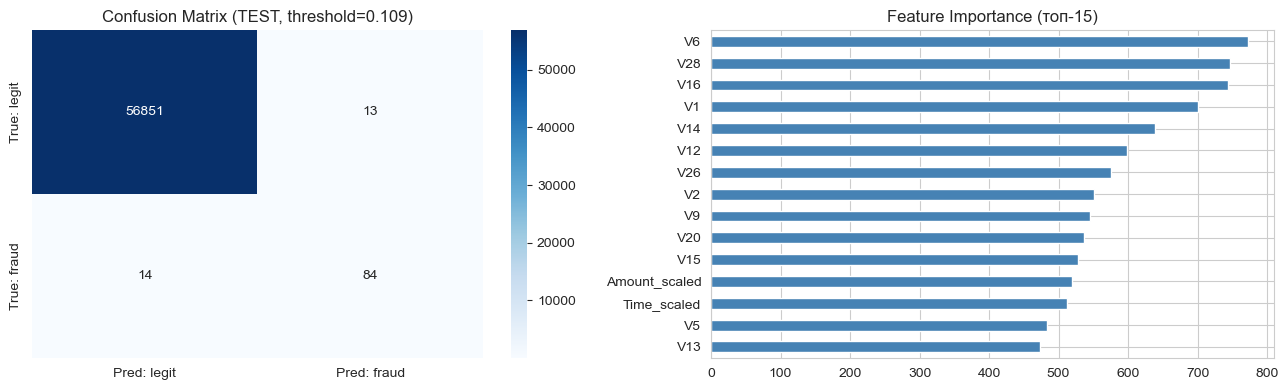

              precision    recall  f1-score   support

       legit       1.00      1.00      1.00     56864
       fraud       0.87      0.86      0.86        98

    accuracy                           1.00     56962
   macro avg       0.93      0.93      0.93     56962
weighted avg       1.00      1.00      1.00     56962



In [6]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Confusion matrix
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=['Pred: legit', 'Pred: fraud'],
            yticklabels=['True: legit', 'True: fraud'])
axes[0].set_title(f'Confusion Matrix (TEST, threshold={best_threshold:.3f})')

# Feature importance
feat_names = [f'V{i}' for i in range(1, 29)] + ['Amount_scaled', 'Time_scaled']
importance = pd.Series(final_model.feature_importances_, index=feat_names)
importance.nlargest(15).plot(kind='barh', ax=axes[1], color='steelblue')
axes[1].set_title('Feature Importance (топ-15)')
axes[1].invert_yaxis()

plt.tight_layout()
plt.savefig('../artifacts/final_model_evaluation.png', dpi=100, bbox_inches='tight')
plt.show()

print(classification_report(y_test, preds_test, target_names=['legit', 'fraud']))

## 6. Сохранение артефактов

In [7]:
# Модель
joblib.dump(final_model, '../models/final_model.pkl')
print('Сохранено: models/final_model.pkl')

# Порог классификации
threshold_data = {
    'threshold': best_threshold,
    'model':     'LightGBM',
    'val_f1':    round(float(f1_scores[best_idx]), 4),
    'val_pr_auc': 0.8359,
}
with open('../models/threshold.json', 'w') as f:
    json.dump(threshold_data, f, indent=2)
print('Сохранено: models/threshold.json')

# model_card.md
model_card = f"""# Model Card — LightGBM Fraud Detector

## Описание
Модель для детекции мошеннических банковских транзакций.

## Метрики (test-выборка)
- PR-AUC:  {test_metrics['pr_auc']}
- ROC-AUC: {test_metrics['roc_auc']}
- F1:      {test_metrics['f1']}
- Порог классификации: {best_threshold:.4f}

## Входные данные
- Time, Amount (нормализованы StandardScaler)
- V1–V28 (PCA-компоненты, без изменений)

## Ограничения
- Обучена на данных 2013 года (European cardholders)
- Признаки анонимизированы — feature engineering невозможен
- Не рекомендуется использовать без мониторинга data drift
"""
with open('../models/model_card.md', 'w') as f:
    f.write(model_card)
print('Сохранено: models/model_card.md')

print('\nВсе артефакты сохранены в models/')

Сохранено: models/final_model.pkl
Сохранено: models/threshold.json
Сохранено: models/model_card.md

Все артефакты сохранены в models/


## 7. Итоги Сессии 3

In [8]:
print('=' * 50)
print('ИТОГИ СЕССИИ 3')
print('=' * 50)
print('Финальная модель: LightGBM')
print(f'Порог: {best_threshold:.4f}')
print(f'TEST PR-AUC:  {test_metrics["pr_auc"]}')
print(f'TEST ROC-AUC: {test_metrics["roc_auc"]}')
print(f'TEST F1:      {test_metrics["f1"]}')
print()
print('Артефакты:')
print('  models/final_model.pkl')
print('  models/preprocessor.pkl')
print('  models/threshold.json')
print('  models/model_card.md')
print()
print('Следующий шаг: Сессия 4 — FastAPI сервис + Docker')

ИТОГИ СЕССИИ 3
Финальная модель: LightGBM
Порог: 0.1095
TEST PR-AUC:  0.886
TEST ROC-AUC: 0.979
TEST F1:      0.8615

Артефакты:
  models/final_model.pkl
  models/preprocessor.pkl
  models/threshold.json
  models/model_card.md

Следующий шаг: Сессия 4 — FastAPI сервис + Docker
